In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\maryu\Health_Dataset_50_Records (1).csv')
print("Loaded successfully! Shape:", df.shape)
print(df.head())

Loaded successfully! Shape: (50, 8)
  Patient_ID  Age  Gender  Weight_kg  Height_cm Blood_Pressure  Heart_Rate  \
0       P001   25    Male       95.1        153         132/66          92   
1       P002   31    Male       96.4        171         115/85          86   
2       P003   61    Male       57.9        160         127/68          86   
3       P004   68    Male       84.3        161         113/73          93   
4       P005   54  Female       80.2        154         112/82          79   

   Cholesterol_mg_dL  
0                199  
1                252  
2                171  
3                240  
4                213  


In [7]:
df = df.drop(columns=['Patient_ID'])

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(columns=['Blood_Pressure'])

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

df = df[['Age', 'Gender', 'Weight_kg', 'Height_cm',
         'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Cholesterol_mg_dL']]

print("Preprocessed! Shape:", df.shape)
print(df.head())

Preprocessed! Shape: (50, 8)
   Age  Gender  Weight_kg  Height_cm  Systolic_BP  Diastolic_BP  Heart_Rate  \
0   25       0       95.1        153          132            66          92   
1   31       0       96.4        171          115            85          86   
2   61       0       57.9        160          127            68          86   
3   68       0       84.3        161          113            73          93   
4   54       1       80.2        154          112            82          79   

   Cholesterol_mg_dL  
0                199  
1                252  
2                171  
3                240  
4                213  


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaling done!")
print("Mean:", X_scaled.mean(axis=0).round(2))
print("Std: ", X_scaled.std(axis=0).round(2))

Scaling done!
Mean: [-0.  0. -0. -0.  0.  0. -0. -0.]
Std:  [1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

print("Inertia values:")
for k, val in zip(K_range, inertias):
    print(f"  k={k}: {val:.2f}")

Inertia values:
  k=1: 400.00
  k=2: 330.84
  k=3: 284.16
  k=4: 248.06
  k=5: 225.62
  k=6: 210.80
  k=7: 195.92
  k=8: 182.11
  k=9: 177.45
  k=10: 163.48


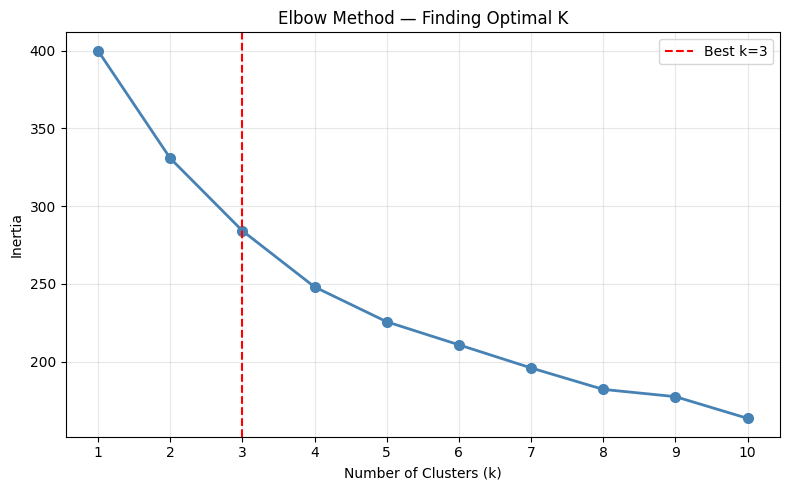

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
plt.axvline(x=3, color='red', linestyle='--', label='Best k=3')
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  k={k}: Silhouette Score = {score:.4f}")

best_k = sil_scores.index(max(sil_scores)) + 2
print(f"\nBest K by Silhouette Score: {best_k}")

  k=2: Silhouette Score = 0.1531
  k=3: Silhouette Score = 0.1648
  k=4: Silhouette Score = 0.1695
  k=5: Silhouette Score = 0.1775
  k=6: Silhouette Score = 0.1761
  k=7: Silhouette Score = 0.1734
  k=8: Silhouette Score = 0.1701
  k=9: Silhouette Score = 0.1261
  k=10: Silhouette Score = 0.1520

Best K by Silhouette Score: 5


In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

labels = kmeans.labels_
df['Cluster'] = labels

print("Cluster labels assigned!")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster labels assigned!

Cluster distribution:
Cluster
0    12
1    19
2    19
Name: count, dtype: int64


In [13]:
cluster_summary = df.groupby('Cluster').mean().round(2)
print("Cluster Profile (mean values):")
print(cluster_summary)

Cluster Profile (mean values):
           Age  Gender  Weight_kg  Height_cm  Systolic_BP  Diastolic_BP  \
Cluster                                                                   
0        44.33    0.00      79.13     173.83       113.92         83.08   
1        52.11    0.16      68.11     165.42       121.11         66.47   
2        41.68    1.00      69.81     174.53       125.95         71.11   

         Heart_Rate  Cholesterol_mg_dL  
Cluster                                 
0             68.67             170.25  
1             88.89             196.79  
2             76.53             205.11  


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PC1 explains: 22.45%
PC2 explains: 17.15%
Total variance explained: 39.59%


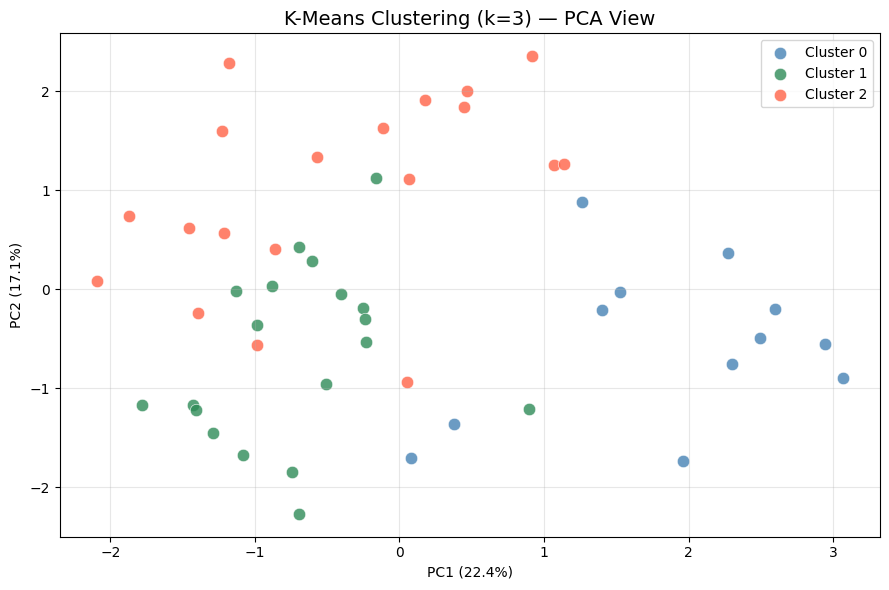

In [15]:
colors = ['steelblue', 'seagreen', 'tomato']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))

for i in range(3):
    mask = labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=cluster_names[i],
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

plt.title('K-Means Clustering (k=3) — PCA View', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

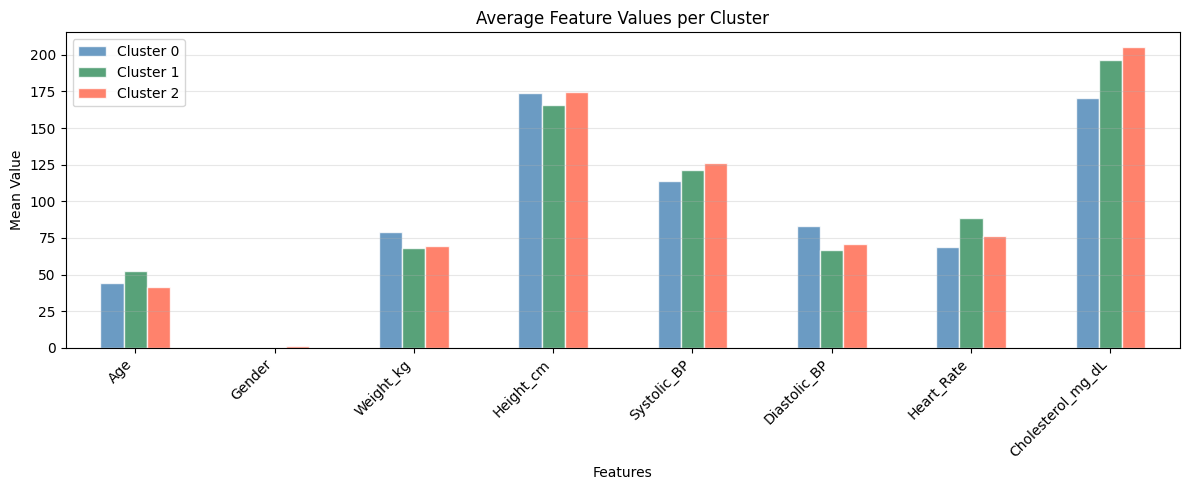

In [16]:
cluster_summary.T.plot(kind='bar', figsize=(12, 5),
                        color=colors, alpha=0.8, edgecolor='white')

plt.title('Average Feature Values per Cluster')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil = silhouette_score(X_scaled, labels)
db  = davies_bouldin_score(X_scaled, labels)
ch  = calinski_harabasz_score(X_scaled, labels)

print("=" * 40)
print("   K-Means Evaluation Metrics (k=3)")
print("=" * 40)
print(f"  Silhouette Score      : {sil:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Score  : {db:.4f}  (lower is better, min=0)")
print(f"  Calinski-Harabasz     : {ch:.4f}  (higher is better)")
print("=" * 40)

   K-Means Evaluation Metrics (k=3)
  Silhouette Score      : 0.1648  (higher is better, max=1)
  Davies-Bouldin Score  : 1.8733  (lower is better, min=0)
  Calinski-Harabasz     : 9.5795  (higher is better)


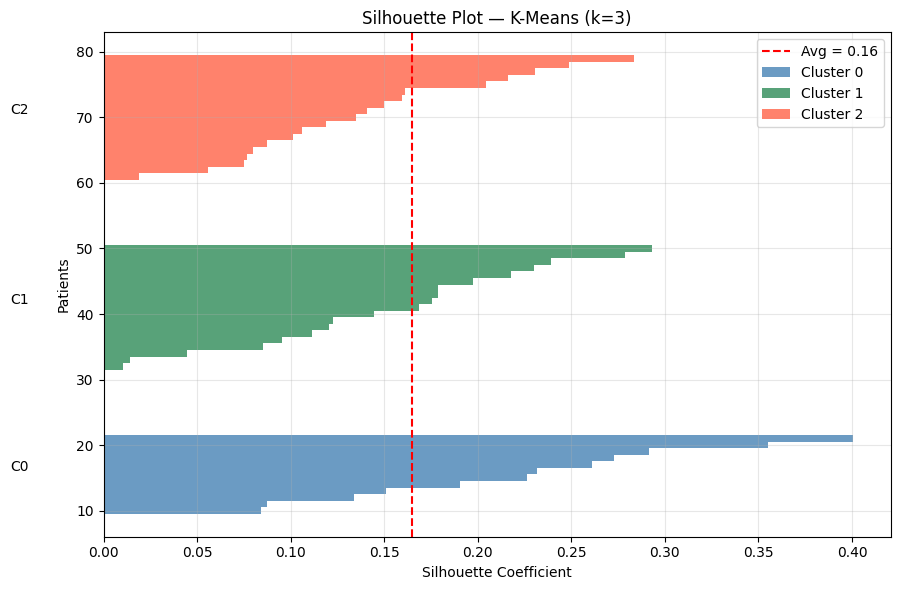

In [18]:
from sklearn.metrics import silhouette_samples
import numpy as np

sil_vals = silhouette_samples(X_scaled, labels)
colors   = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(9, 6))
y_lower = 10

for i in range(3):
    ith_sil = np.sort(sil_vals[labels == i])
    size    = ith_sil.shape[0]
    y_upper = y_lower + size

    plt.barh(range(y_lower, y_upper), ith_sil,
             height=1.0, color=colors[i], alpha=0.8, label=f'Cluster {i}')
    plt.text(-0.05, (y_lower + y_upper) / 2, f'C{i}', fontsize=10)
    y_lower = y_upper + 10

plt.axvline(x=sil, color='red', linestyle='--', label=f'Avg = {sil:.2f}')
plt.title('Silhouette Plot — K-Means (k=3)')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Patients')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
print("=" * 50)
print("        CLUSTER INTERPRETATION SUMMARY")
print("=" * 50)

for i in range(3):
    subset = df[df['Cluster'] == i]
    print(f"\n Cluster {i}  ({len(subset)} patients)")
    print(f"  Avg Age         : {subset['Age'].mean():.1f} years")
    print(f"  Avg Weight      : {subset['Weight_kg'].mean():.1f} kg")
    print(f"  Avg Systolic BP : {subset['Systolic_BP'].mean():.1f} mmHg")
    print(f"  Avg Diastolic BP: {subset['Diastolic_BP'].mean():.1f} mmHg")
    print(f"  Avg Heart Rate  : {subset['Heart_Rate'].mean():.1f} bpm")
    print(f"  Avg Cholesterol : {subset['Cholesterol_mg_dL'].mean():.1f} mg/dL")
    print(f"  Gender (% Female): {subset['Gender'].mean()*100:.1f}%")

        CLUSTER INTERPRETATION SUMMARY

 Cluster 0  (12 patients)
  Avg Age         : 44.3 years
  Avg Weight      : 79.1 kg
  Avg Systolic BP : 113.9 mmHg
  Avg Diastolic BP: 83.1 mmHg
  Avg Heart Rate  : 68.7 bpm
  Avg Cholesterol : 170.2 mg/dL
  Gender (% Female): 0.0%

 Cluster 1  (19 patients)
  Avg Age         : 52.1 years
  Avg Weight      : 68.1 kg
  Avg Systolic BP : 121.1 mmHg
  Avg Diastolic BP: 66.5 mmHg
  Avg Heart Rate  : 88.9 bpm
  Avg Cholesterol : 196.8 mg/dL
  Gender (% Female): 15.8%

 Cluster 2  (19 patients)
  Avg Age         : 41.7 years
  Avg Weight      : 69.8 kg
  Avg Systolic BP : 125.9 mmHg
  Avg Diastolic BP: 71.1 mmHg
  Avg Heart Rate  : 76.5 bpm
  Avg Cholesterol : 205.1 mg/dL
  Gender (% Female): 100.0%


In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [21]:
Z = linkage(X_scaled, method='ward')

print("Linkage matrix shape:", Z.shape)
print("First 5 merges:")
print(Z[:5].round(3))

Linkage matrix shape: (49, 4)
First 5 merges:
[[15.    24.     1.055  2.   ]
 [14.    20.     1.109  2.   ]
 [ 2.    35.     1.417  2.   ]
 [33.    36.     1.536  2.   ]
 [ 8.    38.     1.661  2.   ]]


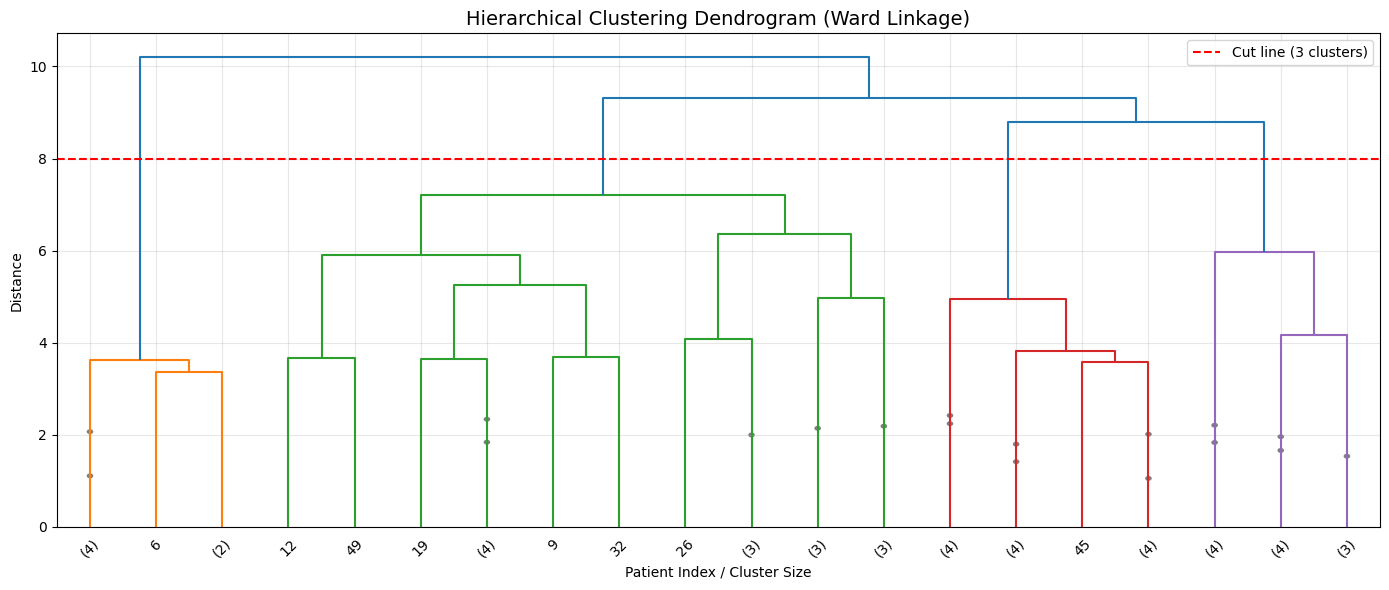

In [22]:
plt.figure(figsize=(14, 6))

dendrogram(Z,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True,
           color_threshold=8)

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Patient Index / Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=8, color='red', linestyle='--', label='Cut line (3 clusters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
hc_labels = fcluster(Z, t=3, criterion='maxclust')

# fcluster starts from 1, convert to 0-based
hc_labels = hc_labels - 1

df['HC_Cluster'] = hc_labels

print("Cluster labels assigned!")
print("\nCluster distribution:")
print(df['HC_Cluster'].value_counts().sort_index())

Cluster labels assigned!

Cluster distribution:
HC_Cluster
0     7
1    19
2    24
Name: count, dtype: int64


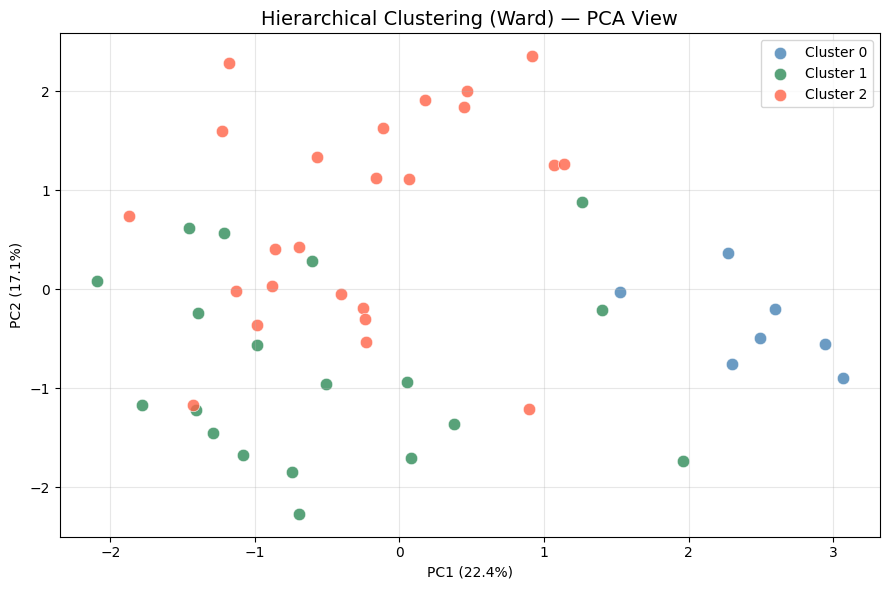

In [24]:
colors = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(9, 6))

for i in range(3):
    mask = hc_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

plt.title('Hierarchical Clustering (Ward) — PCA View', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
hc_summary = df.groupby('HC_Cluster').mean().round(2)
print("Hierarchical Cluster Profiles:")
print(hc_summary)

Hierarchical Cluster Profiles:
              Age  Gender  Weight_kg  Height_cm  Systolic_BP  Diastolic_BP  \
HC_Cluster                                                                   
0           57.86    0.00      74.21     177.43       112.14         84.57   
1           41.32    0.42      81.22     166.00       117.26         72.11   
2           46.83    0.58      62.80     172.88       127.00         68.71   

            Heart_Rate  Cholesterol_mg_dL  Cluster  
HC_Cluster                                          
0                64.29             159.29     0.00  
1                83.37             220.37     1.05  
2                80.54             182.38     1.54  


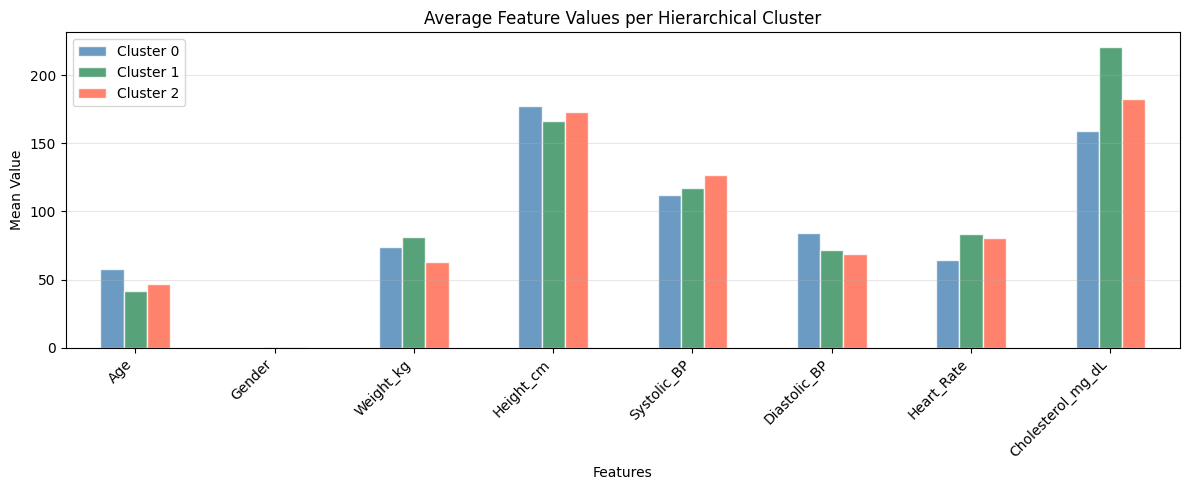

In [26]:
hc_summary.drop(columns=['Cluster']).T.plot(kind='bar', figsize=(12, 5),
                                             color=colors, alpha=0.8,
                                             edgecolor='white')

plt.title('Average Feature Values per Hierarchical Cluster')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.legend(['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [27]:
sil = silhouette_score(X_scaled, hc_labels)
db  = davies_bouldin_score(X_scaled, hc_labels)
ch  = calinski_harabasz_score(X_scaled, hc_labels)

print("=" * 45)
print("  Hierarchical Clustering Evaluation (k=3)")
print("=" * 45)
print(f"  Silhouette Score      : {sil:.4f}  (higher is better)")
print(f"  Davies-Bouldin Score  : {db:.4f}  (lower is better)")
print(f"  Calinski-Harabasz     : {ch:.4f}  (higher is better)")
print("=" * 45)

  Hierarchical Clustering Evaluation (k=3)
  Silhouette Score      : 0.1221  (higher is better)
  Davies-Bouldin Score  : 2.1350  (lower is better)
  Calinski-Harabasz     : 7.3661  (higher is better)


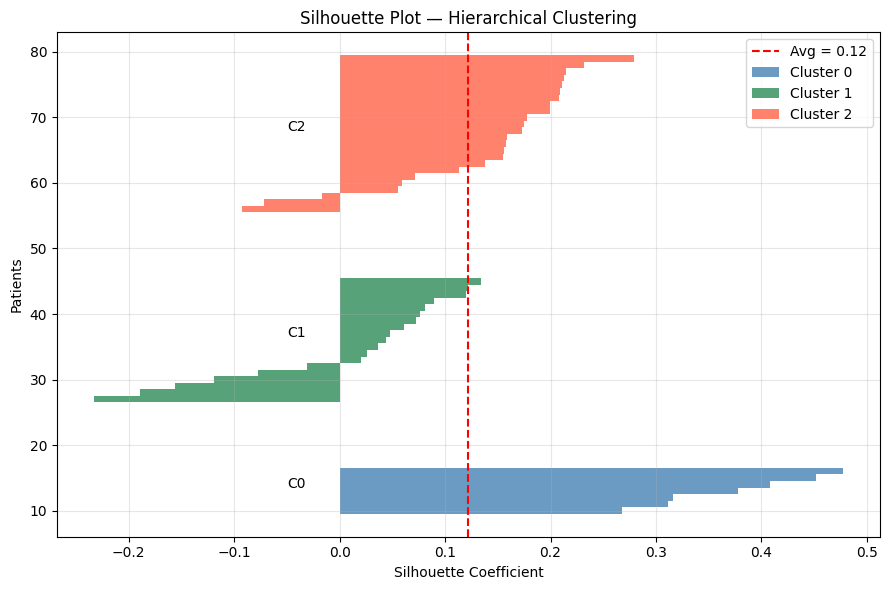

In [28]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_scaled, hc_labels)

plt.figure(figsize=(9, 6))
y_lower = 10

for i in range(3):
    ith_sil = np.sort(sil_vals[hc_labels == i])
    size    = ith_sil.shape[0]
    y_upper = y_lower + size

    plt.barh(range(y_lower, y_upper), ith_sil,
             height=1.0, color=colors[i], alpha=0.8, label=f'Cluster {i}')
    plt.text(-0.05, (y_lower + y_upper) / 2, f'C{i}', fontsize=10)
    y_lower = y_upper + 10

plt.axvline(x=sil, color='red', linestyle='--', label=f'Avg = {sil:.2f}')
plt.title('Silhouette Plot — Hierarchical Clustering')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Patients')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(labels, hc_labels)

print("=" * 45)
print("   K-Means  vs  Hierarchical Comparison")
print("=" * 45)
print(f"  Adjusted Rand Index   : {ari:.4f}")
print(f"  (1.0 = perfect match, 0.0 = random)")
print()
print("  K-Means Silhouette    :", round(silhouette_score(X_scaled, labels), 4))
print("  Hierarchical Silhouette:", round(sil, 4))
print()
print("  K-Means DB Score      :", round(davies_bouldin_score(X_scaled, labels), 4))
print("  Hierarchical DB Score :", round(db, 4))
print("=" * 45)

   K-Means  vs  Hierarchical Comparison
  Adjusted Rand Index   : 0.1812
  (1.0 = perfect match, 0.0 = random)

  K-Means Silhouette    : 0.1648
  Hierarchical Silhouette: 0.1221

  K-Means DB Score      : 1.8733
  Hierarchical DB Score : 2.135


In [30]:
print("=" * 50)
print("     HIERARCHICAL CLUSTER INTERPRETATION")
print("=" * 50)

for i in range(3):
    subset = df[df['HC_Cluster'] == i]
    print(f"\n Cluster {i}  ({len(subset)} patients)")
    print(f"  Avg Age          : {subset['Age'].mean():.1f} years")
    print(f"  Avg Weight       : {subset['Weight_kg'].mean():.1f} kg")
    print(f"  Avg Systolic BP  : {subset['Systolic_BP'].mean():.1f} mmHg")
    print(f"  Avg Diastolic BP : {subset['Diastolic_BP'].mean():.1f} mmHg")
    print(f"  Avg Heart Rate   : {subset['Heart_Rate'].mean():.1f} bpm")
    print(f"  Avg Cholesterol  : {subset['Cholesterol_mg_dL'].mean():.1f} mg/dL")
    print(f"  Gender (% Female): {subset['Gender'].mean()*100:.1f}%")

     HIERARCHICAL CLUSTER INTERPRETATION

 Cluster 0  (7 patients)
  Avg Age          : 57.9 years
  Avg Weight       : 74.2 kg
  Avg Systolic BP  : 112.1 mmHg
  Avg Diastolic BP : 84.6 mmHg
  Avg Heart Rate   : 64.3 bpm
  Avg Cholesterol  : 159.3 mg/dL
  Gender (% Female): 0.0%

 Cluster 1  (19 patients)
  Avg Age          : 41.3 years
  Avg Weight       : 81.2 kg
  Avg Systolic BP  : 117.3 mmHg
  Avg Diastolic BP : 72.1 mmHg
  Avg Heart Rate   : 83.4 bpm
  Avg Cholesterol  : 220.4 mg/dL
  Gender (% Female): 42.1%

 Cluster 2  (24 patients)
  Avg Age          : 46.8 years
  Avg Weight       : 62.8 kg
  Avg Systolic BP  : 127.0 mmHg
  Avg Diastolic BP : 68.7 mmHg
  Avg Heart Rate   : 80.5 bpm
  Avg Cholesterol  : 182.4 mg/dL
  Gender (% Female): 58.3%


In [31]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


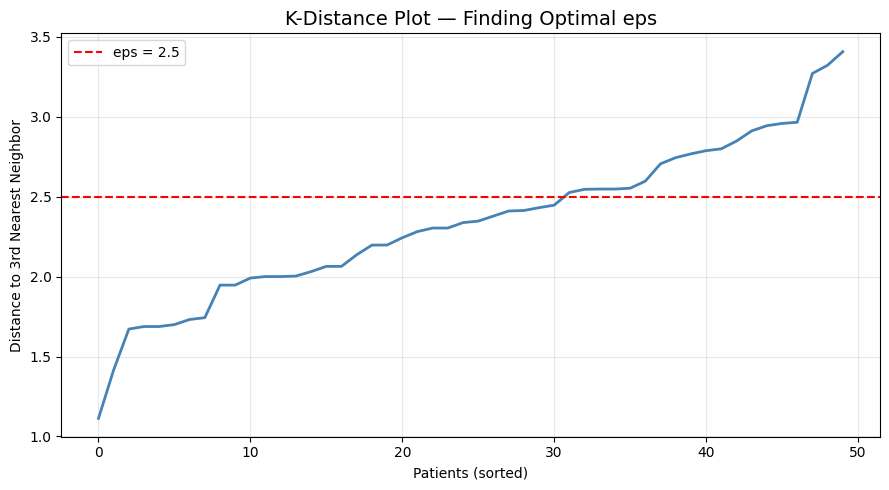

Look for the 'elbow' in the curve — that is your best eps value


In [32]:
# Use k=3 (min_samples we will use)
neighbors = NearestNeighbors(n_neighbors=3)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

# Sort distances to 3rd nearest neighbor
distances = np.sort(distances[:, 2], axis=0)

plt.figure(figsize=(9, 5))
plt.plot(distances, color='steelblue', linewidth=2)
plt.axhline(y=2.5, color='red', linestyle='--', label='eps = 2.5')
plt.title('K-Distance Plot — Finding Optimal eps', fontsize=14)
plt.xlabel('Patients (sorted)')
plt.ylabel('Distance to 3rd Nearest Neighbor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Look for the 'elbow' in the curve — that is your best eps value")

In [33]:
print("Testing different eps values:")
print("=" * 45)

for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    db = DBSCAN(eps=eps, min_samples=3)
    db_labels = db.fit_predict(X_scaled)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise    = list(db_labels).count(-1)
    print(f"  eps={eps} → Clusters: {n_clusters}  |  Outliers: {n_noise}")

print("=" * 45)
print("We will use eps=2.5 (gives clean clusters with some outliers)")

Testing different eps values:
  eps=1.5 → Clusters: 1  |  Outliers: 46
  eps=2.0 → Clusters: 3  |  Outliers: 31
  eps=2.5 → Clusters: 2  |  Outliers: 13
  eps=3.0 → Clusters: 1  |  Outliers: 2
  eps=3.5 → Clusters: 1  |  Outliers: 0
We will use eps=2.5 (gives clean clusters with some outliers)


In [34]:
db = DBSCAN(eps=2.5, min_samples=3)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

df['DBSCAN_Cluster'] = db_labels

print("=" * 40)
print("        DBSCAN Results")
print("=" * 40)
print(f"  Number of Clusters : {n_clusters}")
print(f"  Outlier Patients   : {n_noise}")
print(f"  Core Patients      : {50 - n_noise}")
print("=" * 40)
print("\nCluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())
print("\n(-1 means outlier/noise)")

        DBSCAN Results
  Number of Clusters : 2
  Outlier Patients   : 13
  Core Patients      : 37

Cluster distribution:
DBSCAN_Cluster
-1    13
 0    32
 1     5
Name: count, dtype: int64

(-1 means outlier/noise)


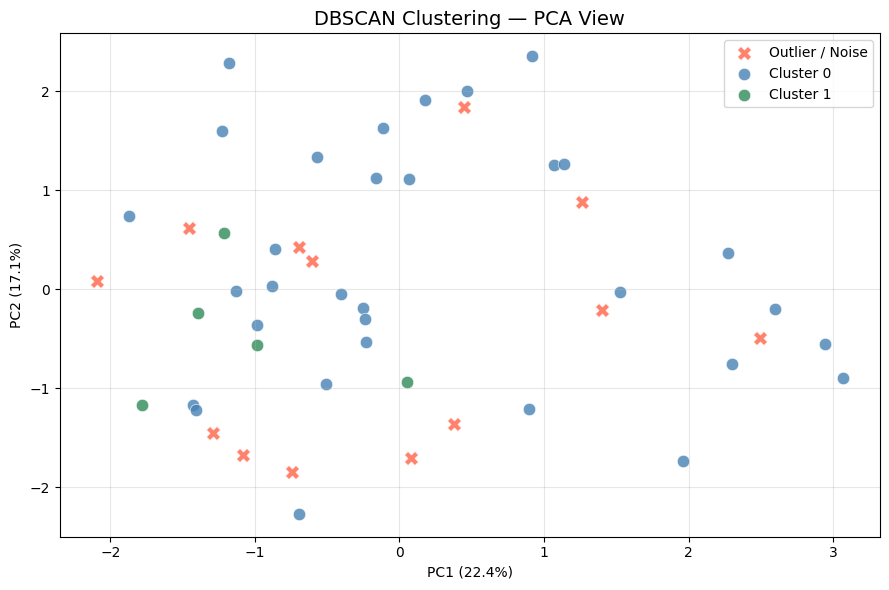

In [35]:
plt.figure(figsize=(9, 6))

# Plot core clusters
unique_labels = sorted(set(db_labels))
colors_map = {0: 'steelblue', 1: 'seagreen', -1: 'tomato'}
labels_map = {0: 'Cluster 0', 1: 'Cluster 1', -1: 'Outlier / Noise'}
markers_map = {0: 'o', 1: 'o', -1: 'X'}
sizes_map = {0: 80, 1: 80, -1: 100}

for label in unique_labels:
    mask = db_labels == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_map[label],
                label=labels_map[label],
                marker=markers_map[label],
                s=sizes_map[label],
                alpha=0.8,
                edgecolors='white',
                linewidth=0.5)

plt.title('DBSCAN Clustering — PCA View', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

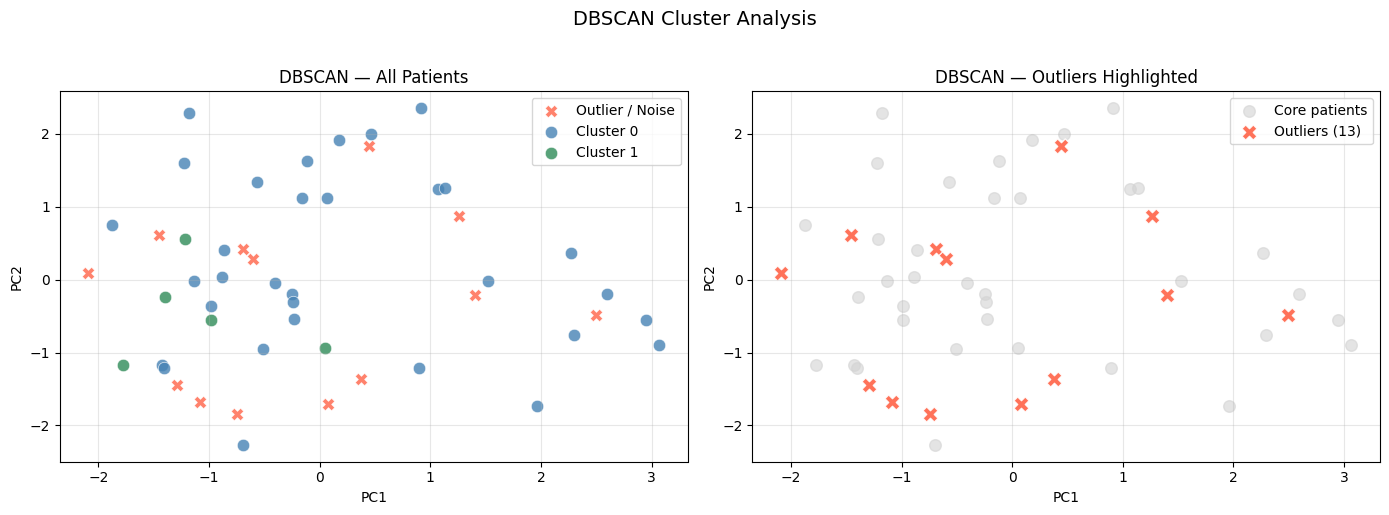

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — all patients colored by cluster
for label in unique_labels:
    mask = db_labels == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_map[label], label=labels_map[label],
                    marker=markers_map[label], s=80, alpha=0.8,
                    edgecolors='white', linewidth=0.5)
axes[0].set_title('DBSCAN — All Patients')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right — only outliers highlighted
normal = db_labels != -1
outlier = db_labels == -1
axes[1].scatter(X_pca[normal, 0], X_pca[normal, 1],
                c='lightgray', label='Core patients', s=70, alpha=0.6)
axes[1].scatter(X_pca[outlier, 0], X_pca[outlier, 1],
                c='tomato', label=f'Outliers ({n_noise})', 
                marker='X', s=120, alpha=0.9, edgecolors='white')
axes[1].set_title('DBSCAN — Outliers Highlighted')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DBSCAN Cluster Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Only evaluate on non-outlier points
mask_core = db_labels != -1

sil = silhouette_score(X_scaled[mask_core], db_labels[mask_core])
db_score = davies_bouldin_score(X_scaled[mask_core], db_labels[mask_core])
ch = calinski_harabasz_score(X_scaled[mask_core], db_labels[mask_core])

print("=" * 45)
print("     DBSCAN Evaluation Metrics")
print("=" * 45)
print(f"  Silhouette Score      : {sil:.4f}  (higher is better)")
print(f"  Davies-Bouldin Score  : {db_score:.4f}  (lower is better)")
print(f"  Calinski-Harabasz     : {ch:.4f}  (higher is better)")
print(f"  Core patients used    : {mask_core.sum()} / 50")
print("=" * 45)

     DBSCAN Evaluation Metrics
  Silhouette Score      : 0.1324  (higher is better)
  Davies-Bouldin Score  : 1.6014  (lower is better)
  Calinski-Harabasz     : 4.5520  (higher is better)
  Core patients used    : 37 / 50


In [39]:
outlier_df = df[df['DBSCAN_Cluster'] == -1].copy()
outlier_df = outlier_df.drop(columns=['DBSCAN_Cluster', 'Cluster', 'HC_Cluster'])

print("=" * 50)
print(f"   OUTLIER PATIENTS ({len(outlier_df)} total)")
print("=" * 50)
print(outlier_df.to_string())
print("\nOutlier Averages:")
print(outlier_df.mean().round(2))

   OUTLIER PATIENTS (13 total)
    Age  Gender  Weight_kg  Height_cm  Systolic_BP  Diastolic_BP  Heart_Rate  Cholesterol_mg_dL
0    25       0       95.1        153          132            66          92                199
1    31       0       96.4        171          115            85          86                252
6    68       0       92.5        173          132            87          57                177
9    54       0       59.2        151          103            61          67                252
11   24       1       95.3        187          133            66          55                188
12   55       0       98.2        185          104            61          90                259
13   19       1       91.8        169          137            69          77                244
17   20       0       84.3        164          109            78          75                218
26   22       0       84.6        188          139            85          80                164
30   41  

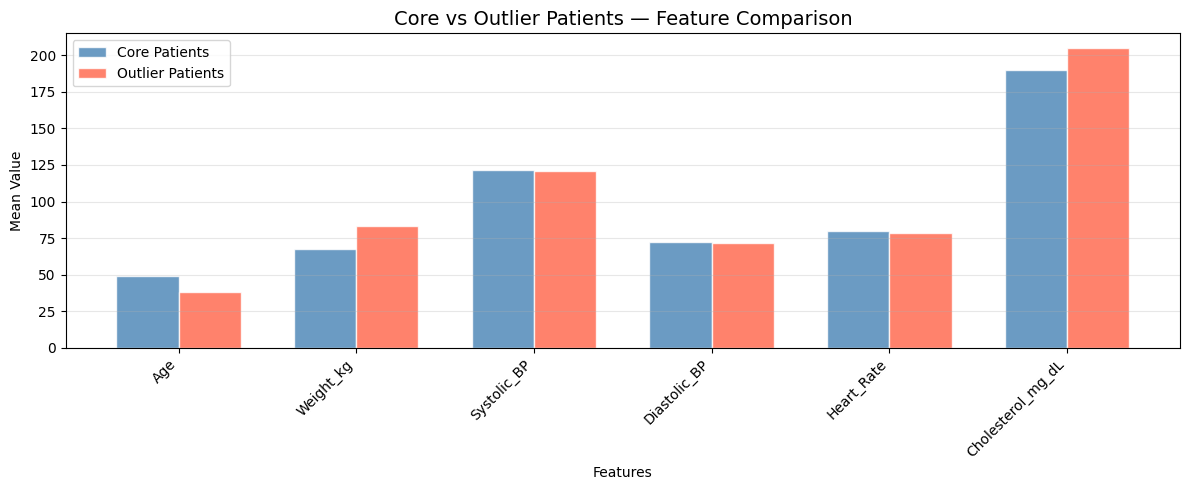

In [40]:
core_df    = df[df['DBSCAN_Cluster'] != -1]
outlier_df = df[df['DBSCAN_Cluster'] == -1]

features = ['Age', 'Weight_kg', 'Systolic_BP', 
            'Diastolic_BP', 'Heart_Rate', 'Cholesterol_mg_dL']

core_means    = core_df[features].mean()
outlier_means = outlier_df[features].mean()

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, core_means,    width, label='Core Patients',   
        color='steelblue', alpha=0.8, edgecolor='white')
plt.bar(x + width/2, outlier_means, width, label='Outlier Patients', 
        color='tomato',    alpha=0.8, edgecolor='white')

plt.title('Core vs Outlier Patients — Feature Comparison', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.xticks(x, features, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [41]:
print("=" * 55)
print("     FULL MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"  {'Model':<25} {'Silhouette':>12} {'DB Score':>10}")
print("-" * 55)
print(f"  {'K-Means (k=3)':<25} {silhouette_score(X_scaled, labels):>12.4f} {davies_bouldin_score(X_scaled, labels):>10.4f}")
print(f"  {'Hierarchical (k=3)':<25} {silhouette_score(X_scaled, hc_labels):>12.4f} {davies_bouldin_score(X_scaled, hc_labels):>10.4f}")
print(f"  {'DBSCAN (core only)':<25} {sil:>12.4f} {db_score:>10.4f}")
print("=" * 55)
print("  Silhouette → higher is better")
print("  DB Score   → lower is better")

     FULL MODEL COMPARISON SUMMARY
  Model                       Silhouette   DB Score
-------------------------------------------------------
  K-Means (k=3)                   0.1648     1.8733
  Hierarchical (k=3)              0.1221     2.1350
  DBSCAN (core only)              0.1324     1.6014
  Silhouette → higher is better
  DB Score   → lower is better


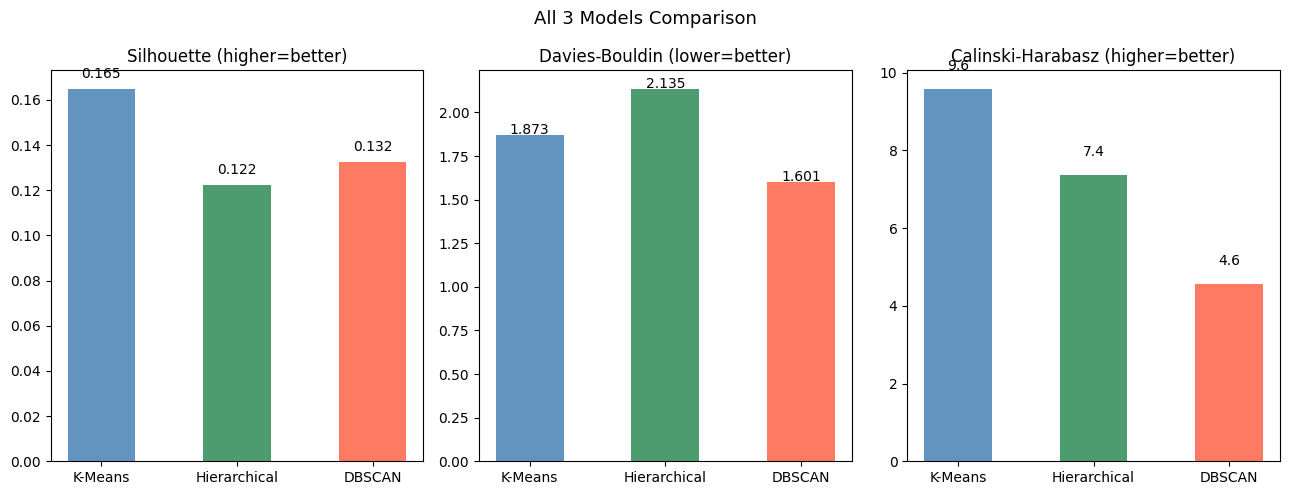

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

models = ['K-Means', 'Hierarchical', 'DBSCAN']
c = ['steelblue', 'seagreen', 'tomato']
x = np.arange(3)

s = [silhouette_score(X_scaled, labels),
     silhouette_score(X_scaled, hc_labels),
     silhouette_score(X_scaled[mask_core], db_labels[mask_core])]

d = [davies_bouldin_score(X_scaled, labels),
     davies_bouldin_score(X_scaled, hc_labels),
     davies_bouldin_score(X_scaled[mask_core], db_labels[mask_core])]

ch = [calinski_harabasz_score(X_scaled, labels),
      calinski_harabasz_score(X_scaled, hc_labels),
      calinski_harabasz_score(X_scaled[mask_core], db_labels[mask_core])]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].bar(x, s, color=c, alpha=0.85, width=0.5)
axes[0].set_title('Silhouette (higher=better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
for i, v in enumerate(s):
    axes[0].text(i, v+0.005, f'{v:.3f}', ha='center')

axes[1].bar(x, d, color=c, alpha=0.85, width=0.5)
axes[1].set_title('Davies-Bouldin (lower=better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
for i, v in enumerate(d):
    axes[1].text(i, v+0.005, f'{v:.3f}', ha='center')

axes[2].bar(x, ch, color=c, alpha=0.85, width=0.5)
axes[2].set_title('Calinski-Harabasz (higher=better)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models)
for i, v in enumerate(ch):
    axes[2].text(i, v+0.5, f'{v:.1f}', ha='center')

plt.suptitle('All 3 Models Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [46]:
pca_full = PCA(n_components=8)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("=" * 45)
print("   PCA Explained Variance per Component")
print("=" * 45)
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {e*100:.2f}%  |  Cumulative: {c*100:.2f}%")
print("=" * 45)

   PCA Explained Variance per Component
  PC1: 22.45%  |  Cumulative: 22.45%
  PC2: 17.15%  |  Cumulative: 39.59%
  PC3: 16.08%  |  Cumulative: 55.68%
  PC4: 11.31%  |  Cumulative: 66.99%
  PC5: 10.33%  |  Cumulative: 77.32%
  PC6: 9.84%  |  Cumulative: 87.16%
  PC7: 7.28%  |  Cumulative: 94.44%
  PC8: 5.56%  |  Cumulative: 100.00%


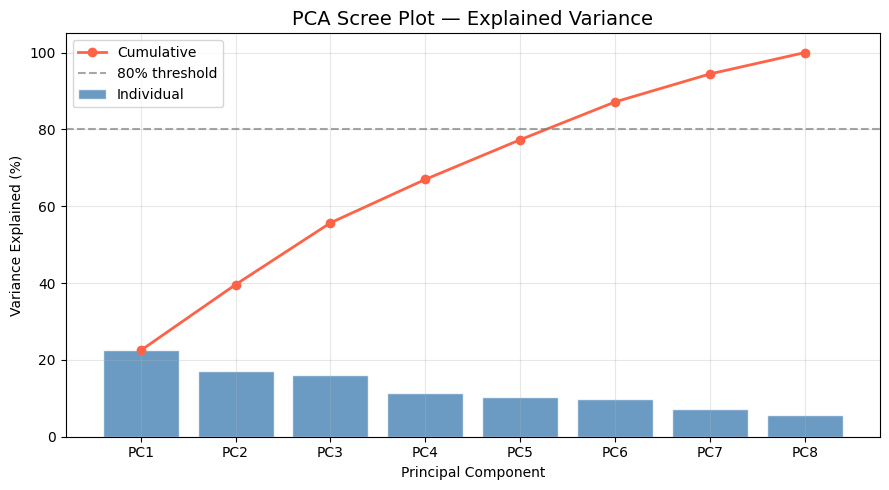

In [47]:
plt.figure(figsize=(9, 5))

plt.bar(range(1, 9), explained * 100,
        color='steelblue', alpha=0.8,
        edgecolor='white', label='Individual')

plt.plot(range(1, 9), cumulative * 100,
         color='tomato', marker='o',
         linewidth=2, label='Cumulative')

plt.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')

plt.title('PCA Scree Plot — Explained Variance', fontsize=14)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.xticks(range(1, 9), [f'PC{i}' for i in range(1, 9)])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print("=" * 45)
print("   PCA 2 Components Summary")
print("=" * 45)
print(f"  PC1 Variance : {pca2.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 Variance : {pca2.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total        : {sum(pca2.explained_variance_ratio_)*100:.2f}%")
print("=" * 45)

   PCA 2 Components Summary
  PC1 Variance : 22.45%
  PC2 Variance : 17.15%
  Total        : 39.59%


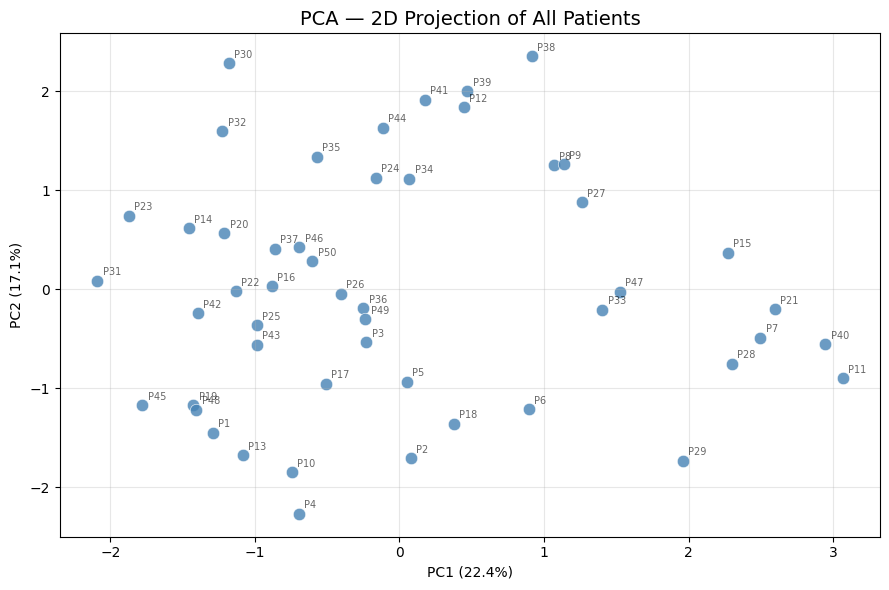

In [49]:
plt.figure(figsize=(9, 6))

plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
            c='steelblue', s=80,
            alpha=0.8, edgecolors='white', linewidth=0.5)

for i in range(len(X_pca2)):
    plt.annotate(f'P{i+1}', (X_pca2[i, 0], X_pca2[i, 1]),
                 fontsize=7, alpha=0.6,
                 xytext=(4, 4), textcoords='offset points')

plt.title('PCA — 2D Projection of All Patients', fontsize=14)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

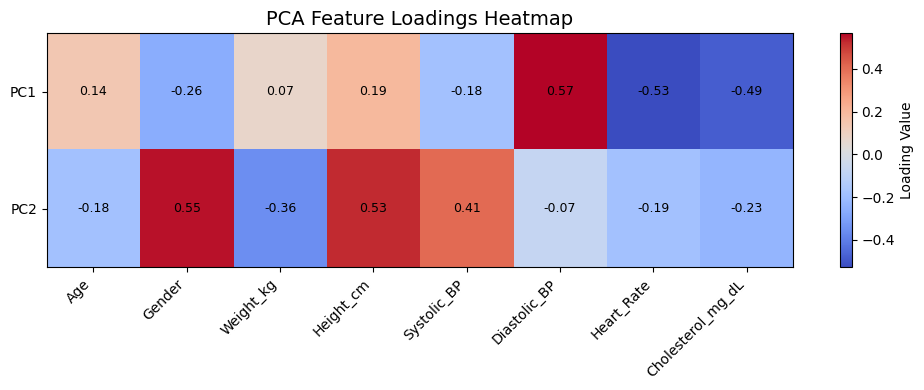

In [50]:
features = ['Age', 'Gender', 'Weight_kg', 'Height_cm',
            'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Cholesterol_mg_dL']

loadings = pca2.components_

plt.figure(figsize=(10, 4))
plt.imshow(loadings, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Loading Value')
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks([0, 1], ['PC1', 'PC2'])
plt.title('PCA Feature Loadings Heatmap', fontsize=14)

for i in range(2):
    for j in range(len(features)):
        plt.text(j, i, f'{loadings[i, j]:.2f}',
                 ha='center', va='center',
                 fontsize=9, color='black')

plt.tight_layout()
plt.show()

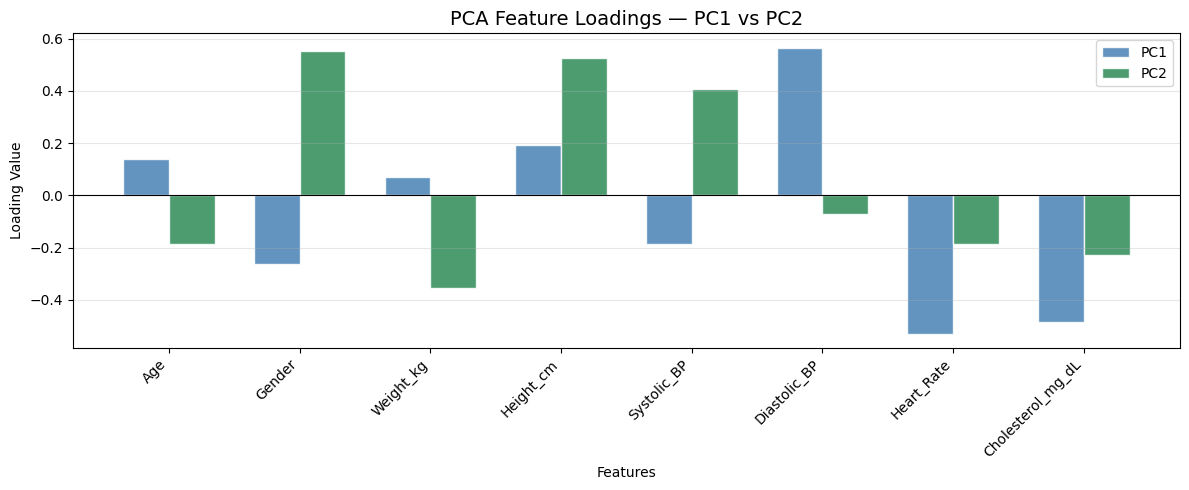

In [51]:
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, loadings[0], width,
        label='PC1', color='steelblue', alpha=0.85, edgecolor='white')
plt.bar(x + width/2, loadings[1], width,
        label='PC2', color='seagreen', alpha=0.85, edgecolor='white')

plt.title('PCA Feature Loadings — PC1 vs PC2', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Loading Value')
plt.xticks(x, features, rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

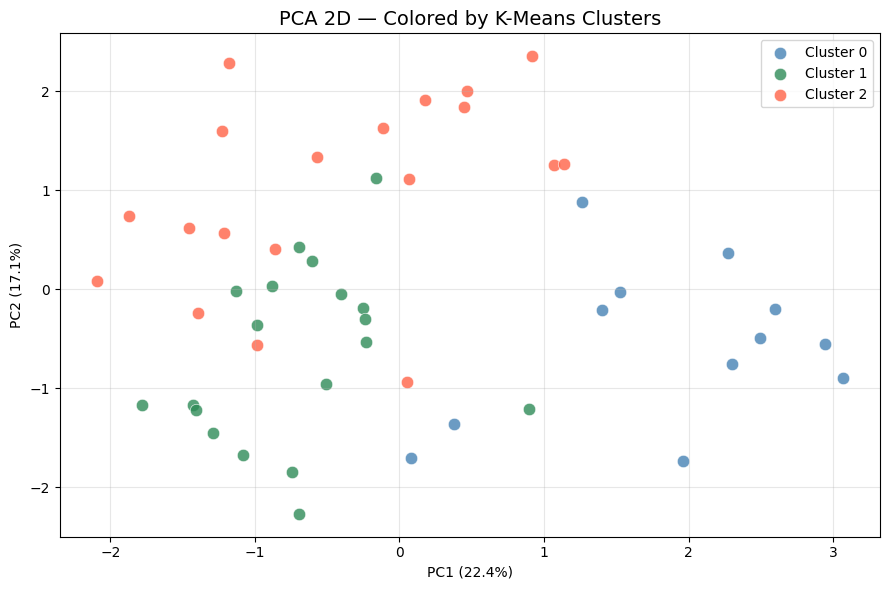

In [52]:
colors = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(9, 6))

for i in range(3):
    mask = labels == i
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8,
                edgecolors='white', linewidth=0.5)

plt.title('PCA 2D — Colored by K-Means Clusters', fontsize=14)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

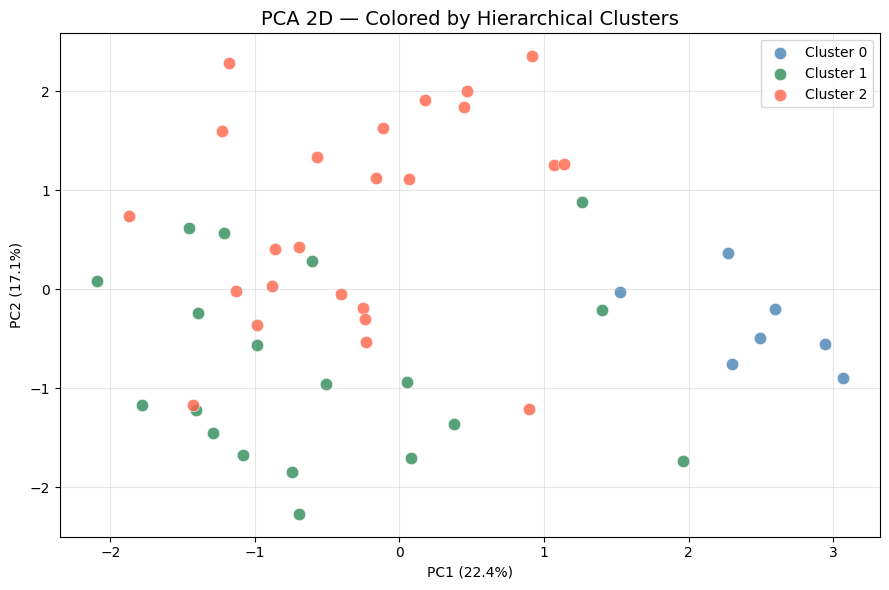

In [53]:
hc_colors = ['steelblue', 'seagreen', 'tomato']

plt.figure(figsize=(9, 6))

for i in range(3):
    mask = hc_labels == i
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=hc_colors[i], label=f'Cluster {i}',
                s=80, alpha=0.8,
                edgecolors='white', linewidth=0.5)

plt.title('PCA 2D — Colored by Hierarchical Clusters', fontsize=14)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

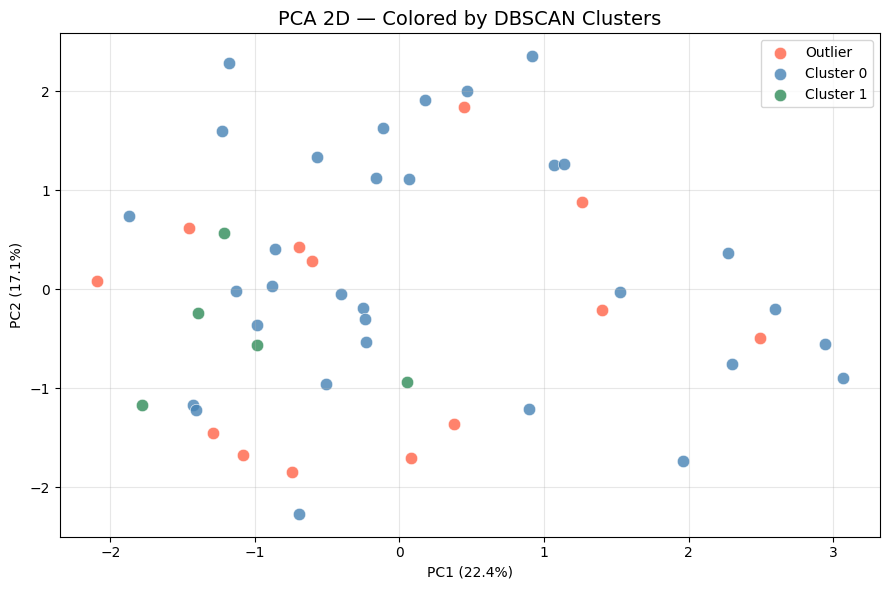

In [54]:
plt.figure(figsize=(9, 6))

colors_db = {0: 'steelblue', 1: 'seagreen', -1: 'tomato'}
labels_db = {0: 'Cluster 0', 1: 'Cluster 1', -1: 'Outlier'}

for label in sorted(set(db_labels)):
    mask = db_labels == label
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                c=colors_db[label],
                label=labels_db[label],
                s=80, alpha=0.8,
                edgecolors='white', linewidth=0.5)

plt.title('PCA 2D — Colored by DBSCAN Clusters', fontsize=14)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

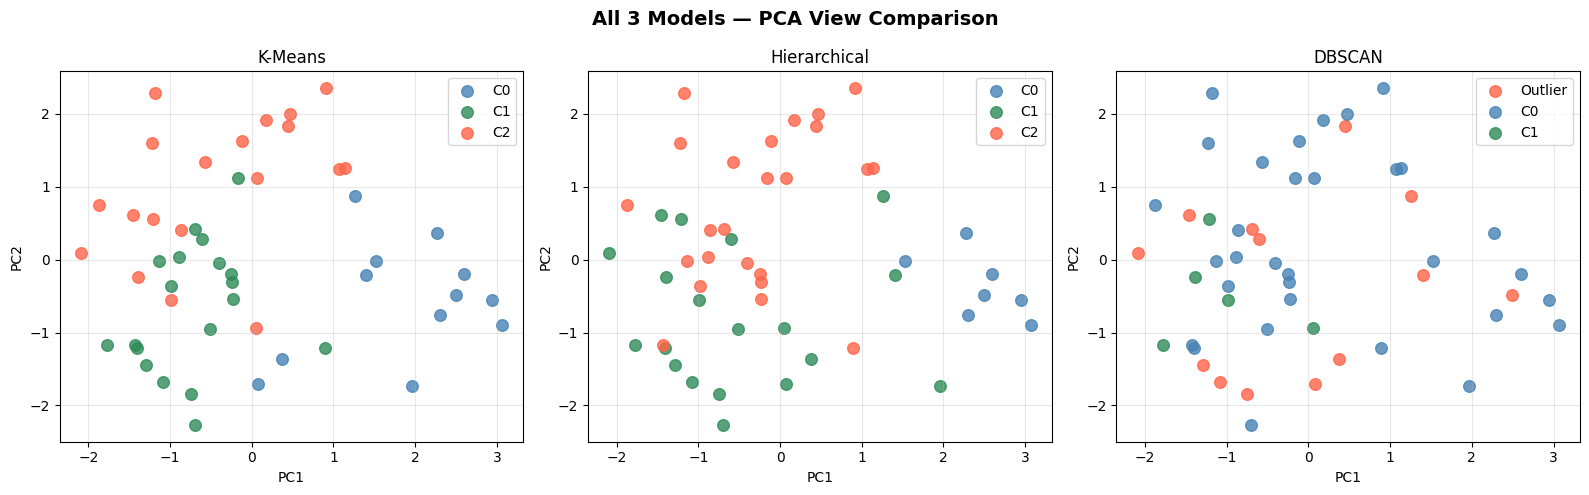

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
c = ['steelblue', 'seagreen', 'tomato']

for i in range(3):
    mask = labels == i
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=c[i], label=f'C{i}', s=70, alpha=0.8)
axes[0].set_title('K-Means')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i in range(3):
    mask = hc_labels == i
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=c[i], label=f'C{i}', s=70, alpha=0.8)
axes[1].set_title('Hierarchical')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

colors_db = {0: 'steelblue', 1: 'seagreen', -1: 'tomato'}
for label in sorted(set(db_labels)):
    mask = db_labels == label
    lbl = 'Outlier' if label == -1 else f'C{label}'
    axes[2].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=colors_db[label], label=lbl, s=70, alpha=0.8)
axes[2].set_title('DBSCAN')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('All 3 Models — PCA View Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()